['0.02233 - 0.06152', ('I3', 'F2', 'A1'), (26.17, 63.34, 90)]
['0.02233 - 0.06152', ('I3', 'F2', 'A1'), (26.17, 63.34, 90)]
['0.03511 - 0.05971', ('G3', 'A1', 'F12'), (53.25, 90, 63.34)]
['-0.03584 - 0.06008', ('I3', 'F3', 'A1'), (26.17, 63.34, 90)]
['-0.02353 - 0.06870', ('G3', 'H2', 'D3'), (53.25, 41.59, 0)]
['0.04336 - 0.05852', ('H3', 'A1', 'F12'), (41.59, 90, 63.34)]
['0.05432 - 0.04967', ('H1', 'A1', 'E2'), (41.59, 90, 72.59)]
['-0.02166 - 0.07071', ('H1', 'F2', 'A1'), (41.59, 63.34, 90)]
['0.03508 - 0.06543', ('G1', 'A1', 'F12'), (53.25, 90, 63.34)]
['0.04058 - 0.06219', ('G3', 'F11', 'A1'), (53.25, 63.34, 90)]
['0.05017 - 0.05665', ('H3', 'F11', 'A1'), (41.59, 63.34, 90)]
['0.04160 - 0.06411', ('G1', 'F11', 'A1'), (53.25, 63.34, 90)]
['0.05843 - 0.05098', ('C1', 'H1', 'C2'), (90, 41.59, 73)]
['0.04892 - 0.06619', ('G3', 'A1', 'F1'), (53.25, 90, 63.34)]
['0.04881 - 0.06668', ('H1', 'E1', 'A1'), (41.59, 72.59, 90)]
['0.04835 - 0.06745', ('G1', 'A1', 'F1'), (53.25, 90, 63.34)]
['0

/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/plotter.py:1051: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=cls.font_size)


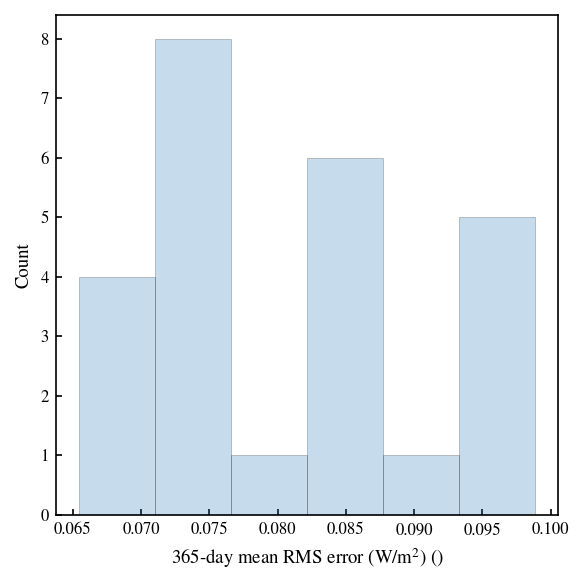

In [3]:
import sys, os
import numpy as np
import SpaceBalls.output_database_manager as db_manager
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
#from SpaceBalls.postproc_EEI_estimation import generate_constellation_stacking_animations
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series
from SpaceBalls.utils import normal_smoother, nanrms
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
import time


RMS_lim = 0.1
window_days = 365
window_name = str(window_days) + '-day'

EEI_name = "EEI_truth_1"
#TODO: fix code duplication with compute_rolling_avg_error_time_series
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_time_series = get_true_EEI_time_series(EEI_name)

EEI_smooth_true = normal_smoother(EEI_time_series, full_jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)
# end TODO


best_results = db_manager.retrieve_best_rows(window_days, RMS_lim, n_best=None, 
                                             config_filters={'EEI_truth_idx': int(1),
                                                             'accelerometer_errors_key': None,
                                                             'model_errors_key': None,
                                                             'stacking_frame': 'SFF',
                                                             'grid_name': 'grid_quad_n131',
                                                             'method': 'binary_gridding',
                                                             'fill_zeroes_method': 'theta_s_fit_simplified',
                                                             'avg_method': 'numeric_integral',
                                                             'remove_drag': None,
                                                             'altitude_correction': None,
                                                             'use_recomp_meas': 1,
                                                             'n_sb': 3,
                                                             })
all_rms = [res[1] for res in best_results]
# all_keys = [row[0] for row in results] # best key: '40265d9d7397c205'
# all_rms = [row[1] for row in results]
# all_constellations = [row[2] for row in results]
# sorted_idxs = np.argsort(all_rms)
# best_constellations = [all_constellations[i] for i in sorted_idxs]

#for i, const in enumerate(best_constellations[:70]):
for i, res in enumerate(best_results):
    key, rms, const = res
    error_time_series = np.load(os.path.join(MEDIA_DIR, 'EEI_estimations', 
                                             str(window_days)+'-day_avg_error_time_series', key+'.npy'))
    mean_bias = np.nanmean(error_time_series)
    std = np.sqrt(np.nanmean((error_time_series - mean_bias)**2))

    sb_names = const.split("|")
    const_dicts = [input_manager.get_dicts(sb) for sb in sb_names]

    row = [(f"{mean_bias:.5f} - {std:.5f}"), tuple([d['orbit']['orbit_name'] for d in const_dicts]),
           tuple([d['orbit']['i_0'] for d in const_dicts])]

    print(row)
    #print(f"               Bias: {mean_bias:.5f}")
    #print(f"               STD: {std:.5f}")

Plotter.plot_histogram(all_rms, xlabel=str(window_days)+'-day mean RMS error (W/m$^2$)', normalized=False)

# 7b54acc8701b0625|82c0c7e77260bb76|c1dd568b730da76c
# 7b54acc8701b0625|82c0c7e77260bb76|c1dd568b730da76c




In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

dates = Plotter.jd_to_datetime(mid_day_jd_array)
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

for row in results:
    key, rms, constellation_name = row
    fname = os.path.join(MEDIA_DIR, 'EEI_estimations', window_name+'_avg_error_time_series',
                                             key+'.npy')
    if os.path.exists(fname):
        error_time_series = np.load(fname)
        ax.plot(dates, error_time_series, color='k', alpha=0.01)

ax.axhline(0, color='red')
ax.set_ylabel('1-yr average EEI error (W/m$^2$)')
locator = mdates.AutoDateLocator() # minticks=3, maxticks=7)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

In [ ]:
from SpaceBalls.utils import nanrms

for row in results:
    key, rms, constellation_name = row
    error_time_series = np.load(os.path.join(MEDIA_DIR, 'EEI_estimations', window_name+'_avg_error_time_series',
                                             key+'.npy'))
    EEI_smooth_estimated = error_time_series + EEI_smooth_true_coarse

    Plotter.plot_time_series(mid_day_jd_array,
                        {'True EEI ('+window_name+' avg.)': EEI_smooth_true_coarse,
                        'Estimated EEI ('+window_name+' avg.)': EEI_smooth_estimated},
                        f_width=2.5, f_height=0.5,
                        ylabel='Net TOA flux (W/m$^2$)',
                        y_scatter_dict={'$\phi(t)$ (W/m$^2$)': (full_jd_array, EEI_time_series_180x360)},
                        scatter_alpha=0.007,
                        out_dir=os.path.join(MEDIA_DIR, 'figures', constellation_name),
                        file_name='EEI_estimate_'+window_name,
                        title=constellation_name + ' - RMS: ' + f"{rms:.{4}f}" + 'W/m$^2$',
                        ylim=[np.nanmin(np.concatenate((EEI_smooth_true_coarse, EEI_smooth_estimated)))-0.1,
                              np.nanmax(np.concatenate((EEI_smooth_true_coarse, EEI_smooth_estimated)))+0.1])
    error = EEI_smooth_estimated-EEI_smooth_true_coarse
    Plotter.plot_time_series(mid_day_jd_array,
                        {'Estimation error': error},
                        f_width=2.5, f_height=0.5,
                        ylabel='Error (W/m$^2$)',
                        title=f"Error RMS: {nanrms(error)}")



In [ ]:
from SpaceBalls.postproc_EEI_estimation import generate_constellation_stacking_animations

constellation_name = 'sc_C2|sc_D1|sc_I2'
generate_constellation_stacking_animations('case_5_years', sc_names=constellation_name.split("|"), 
                                            constellation_tag=constellation_name,
                                            n_days=365, n_lon=360, n_lat=180, frame='SFF')

In [ ]:
for row in results:
    key, rms, constellation_name = row
    generate_constellation_stacking_animations('case_5_years', sc_names=constellation_name.split("|"), 
                                            constellation_tag=constellation_name,
                                            n_days=365, n_lon=360, n_lat=180, frame='SFF')